In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, KFold
# from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
from math import sqrt
np.random.seed(42)

#### Getting the data

In [3]:
# Load the california housing dataset
cali_data = fetch_california_housing(as_frame=True)

In [4]:
X = cali_data.data
y = cali_data.target * 100_000  # scale target to actual house price in USD

print(f"Dataset shape: {X.shape}")
X.head()

Dataset shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
y[:5]

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: MedHouseVal, dtype: float64

#### Splitting the data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape} Test shape: {X_test.shape}")

Train shape: (16512, 8) Test shape: (4128, 8)


#### Linear regression

In [9]:
lr = LinearRegression() # define the model
lr.fit(X_train, y_train) # training the model
y_pred_lr = lr.predict(X_test) # performance evaluation on test data

In [10]:
y_test[:5].tolist() # actual first 5 prices

[47700.0, 45800.0, 500000.99999999994, 218600.0, 278000.0]

In [11]:
y_pred_lr[:5].tolist() # predicted first 5 prices

[71912.2841601912,
 176401.65706624184,
 270965.8833431718,
 283892.5930183935,
 260465.72518103058]

In [14]:
rmse = sqrt(mean_squared_error(y_test, y_pred_lr))
rmse

74558.13830127764

In [15]:
# function that returns performance evaluation metrics
def regression_metrics(y_true, y_pred):
    mae = round(mean_absolute_error(y_true, y_pred), 2)
    mse = round(mean_squared_error(y_true, y_pred), 2)
    rmse = round(sqrt(mse), 2)
    mape = round(mean_absolute_percentage_error(y_true, y_pred), 2)
    r2 = round(r2_score(y_true, y_pred), 2)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape, "R2": r2}

In [16]:
# Linear regression evaluation
metrics_lr = regression_metrics(y_test, y_pred_lr)
metrics_lr

{'MAE': 53320.01,
 'MSE': 5558915986.95,
 'RMSE': 74558.14,
 'MAPE': 0.32,
 'R2': 0.58}

In [17]:
# coefficients for the different features
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values(by="coefficient", key=lambda s: s.abs(), ascending=False)
coef_df

,feature,coefficient
3,AveBedrms,78314.490679
0,MedInc,44867.490967
7,Longitude,-43370.806496
6,Latitude,-41979.248659
2,AveRooms,-12332.334283
1,HouseAge,972.425752
5,AveOccup,-352.631849
4,Population,-0.202962


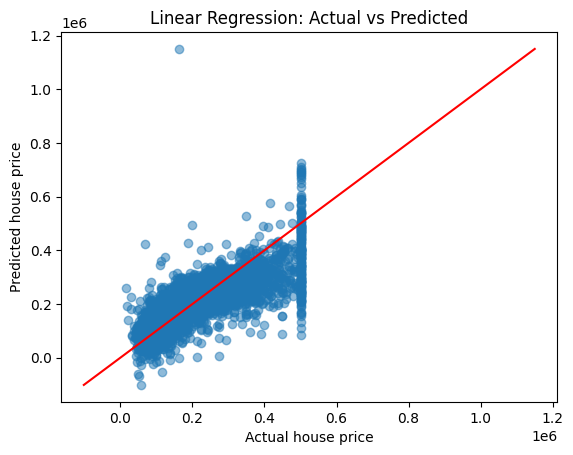

In [11]:
# visualization of predicted vs actual house prices
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.xlabel("Actual house price")
plt.ylabel("Predicted house price")
plt.title("Linear Regression: Actual vs Predicted")
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
plt.plot(lims, lims, "r")
plt.show()

#### Regularization

In [12]:
# Ridge and Lasso regression
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)

# training
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# making predictions for test data
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# performance evaluation
metrics_ridge = regression_metrics(y_test, y_pred_ridge)
metrics_lasso = regression_metrics(y_test, y_pred_lasso)

# creating dataframe from a list of performance metrics dictionaries
pd.DataFrame([metrics_lr, metrics_ridge, metrics_lasso],
             index=["Linear", "Ridge α=1", "Lasso α=1"])

,MAE,MSE,RMSE,MAPE,R2
Linear,53320.01,5.558916e+09,74558.14,0.32,0.58
Ridge α=1,53320.39,5.558035e+09,74552.23,0.32,0.58
Lasso α=1,53320.07,5.558707e+09,74556.74,0.32,0.58


In [13]:
# coefficient comparison
coef_comp = pd.DataFrame({
    "feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
}).set_index("feature")
coef_comp

,Linear,Ridge,Lasso
feature,,,
MedInc,44867.490967,44851.092430,44863.514558
HouseAge,972.425752,972.596535,972.484218
AveRooms,-12332.334283,-12301.415662,-12324.748486
AveBedrms,78314.490679,78141.676063,78272.519515
Population,-0.202962,-0.202581,-0.202790
AveOccup,-352.631849,-352.585878,-352.615173
Latitude,-41979.248659,-41978.690849,-41977.977288
Longitude,-43370.806496,-43368.079268,-43368.925999


---
## Cross-Validation

A single train/test split can be noisy. You might get lucky or unlucky. K-Fold CV solves this by:

1. Splitting data into K equal folds (commonly K=5 or K=10)
2. Training on K-1 folds, validating on the remaining 1
3. Repeating K times, each time with a different validation fold
4. Averaging the K scores = more reliable performance estimate

In [14]:
k = 5  # number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []
mae_scores = []
mape_scores = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"\n--- Fold {fold} ---")

    # Split data manually using indices
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Initialize your model
    model = LinearRegression()

    # Train and make predictions
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Save results
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mae_scores.append(mae)
    mape_scores.append(mape)

    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAE Score: {mae:.2f}")
    print(f"MAPE Score: {mape:.2f}")

    fold += 1


--- Fold 1 ---
RMSE: 74558.14
R² Score: 0.58
MAE Score: 53320.01
MAPE Score: 0.32

--- Fold 2 ---
RMSE: 72639.95
R² Score: 0.61
MAE Score: 53667.97
MAPE Score: 0.32

--- Fold 3 ---
RMSE: 71364.08
R² Score: 0.61
MAE Score: 52917.63
MAPE Score: 0.32

--- Fold 4 ---
RMSE: 71052.85
R² Score: 0.62
MAE Score: 51713.83
MAPE Score: 0.31

--- Fold 5 ---
RMSE: 74510.43
R² Score: 0.59
MAE Score: 54218.98
MAPE Score: 0.32


In [16]:
print(f"Average RMSE: {np.mean(rmse_scores):.2f}")
print(f"Average R² Score: {np.mean(r2_scores):.2f}")
print(f"Average MAE: {np.mean(mae_scores):.2f}")
print(f"Average MAPE: {np.mean(mape_scores):.2f}")

Average RMSE: 72825.09
Average R² Score: 0.60
Average MAE: 53167.68
Average MAPE: 0.32


**Exercise**
1. Standardize the data first and then fit the models. How does this affect the results?
2.  Change the value of `alpha` in the Ridge and Lasso models (for example: `0.01`, `0.1`, `1`, `10`). How does the performance change as `alpha` increases? Show this visually.
3.  Generate polynomial features of degree 2. Fit a Linear Regression model using the transformed dataset. Compare the performance metrics (MAE, RMSE, MAPE, R²) with the original linear regression model.
4.  Use `RepeatedFold` instead of `KFold`. Compare the performance.